In [1]:
import sys
print(sys.executable)

c:\Python313\python.exe


# Water Consumption Forecasting — EDA

Goal: understand the raw dataset before preprocessing/modeling — shape, missing values, per-zone patterns, trends, and anything that will affect how `preprocess.py` should clean it.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline


## 1. Load the raw data

Put the Kaggle CSV in `../data/raw/` before running this cell.

In [3]:
import os

RAW_DIR = "../data/raw"
csv_files = [f for f in os.listdir(RAW_DIR) if f.lower().endswith(".csv")]
print("CSV files found:", csv_files)

assert csv_files, f"No CSV in {RAW_DIR} — download the dataset and place it there first."
df = pd.read_csv(os.path.join(RAW_DIR, csv_files[0]))
print("Shape:", df.shape)
df.head()


CSV files found: ['water_consumption_forecasting.csv']
Shape: (900, 3)


,region,date,consumption_liters
0,North,2023-01-01,11673.07
1,North,2023-01-02,14736.03
2,North,2023-01-03,19370.75
3,North,2023-01-04,17774.55
4,North,2023-01-05,14972.58


## 2. Structure & data types

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   region              900 non-null    str    
 1   date                900 non-null    str    
 2   consumption_liters  900 non-null    float64
dtypes: float64(1), str(2)
memory usage: 34.4 KB


In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
region,900,5,North,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,900,180,2023-01-01,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
consumption_liters,900.0,NaN,NaN,NaN,12753.758211,4278.566391,5004.09,9187.2475,13045.51,16365.0625,19989.83


## 3. Missing values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)


,missing_count,missing_pct
region,0,0.0
date,0,0.0
consumption_liters,0,0.0


## 4. Identify the key columns

Confirm which columns represent zone, date, and consumption — `preprocess.py` auto-detects these by name pattern, so check here that the detected names make sense.

In [7]:
print(list(df.columns))


['region', 'date', 'consumption_liters']


## 5. Duplicates

In [8]:
print("Fully duplicated rows:", df.duplicated().sum())


Fully duplicated rows: 0


## 6. Distribution of the consumption values

Rename the column below to match your actual dataset.

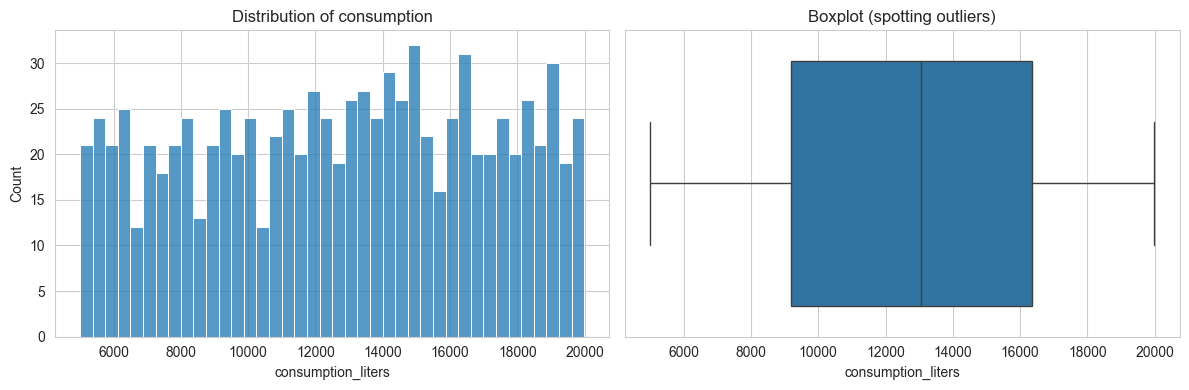

In [9]:
CONSUMPTION_COL = "consumption_liters"   # <-- change to your actual column name
ZONE_COL = "region"                 # <-- change to your actual column name
DATE_COL = "date"                 # <-- change to your actual column name

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[CONSUMPTION_COL], bins=40, ax=axes[0])
axes[0].set_title("Distribution of consumption")
sns.boxplot(x=df[CONSUMPTION_COL], ax=axes[1])
axes[1].set_title("Boxplot (spotting outliers)")
plt.tight_layout()
plt.show()


## 7. Consumption by zone

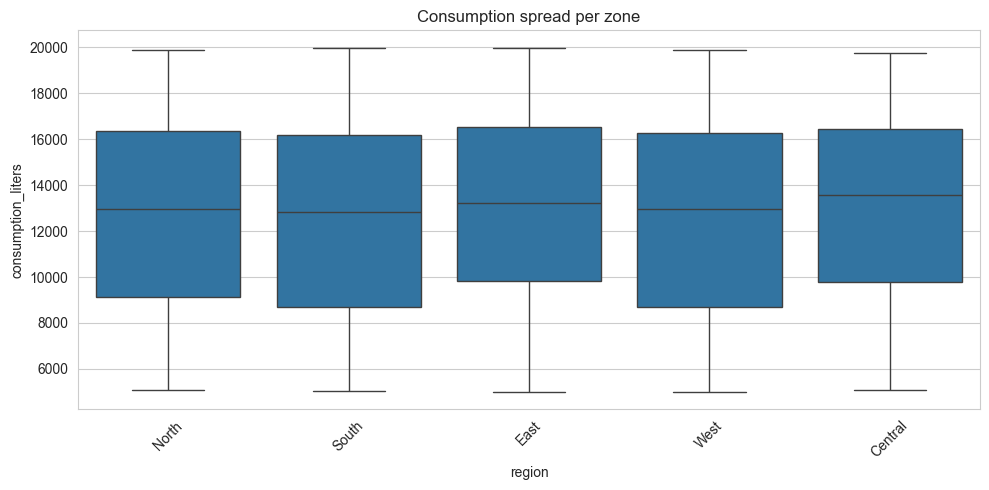

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x=ZONE_COL, y=CONSUMPTION_COL)
plt.xticks(rotation=45)
plt.title("Consumption spread per zone")
plt.tight_layout()
plt.show()


## 8. Trend over time, per zone

This is the most important chart for the forecasting piece — look for seasonality, trend direction, and any zones with unusual jumps (possible data errors, not just real anomalies).

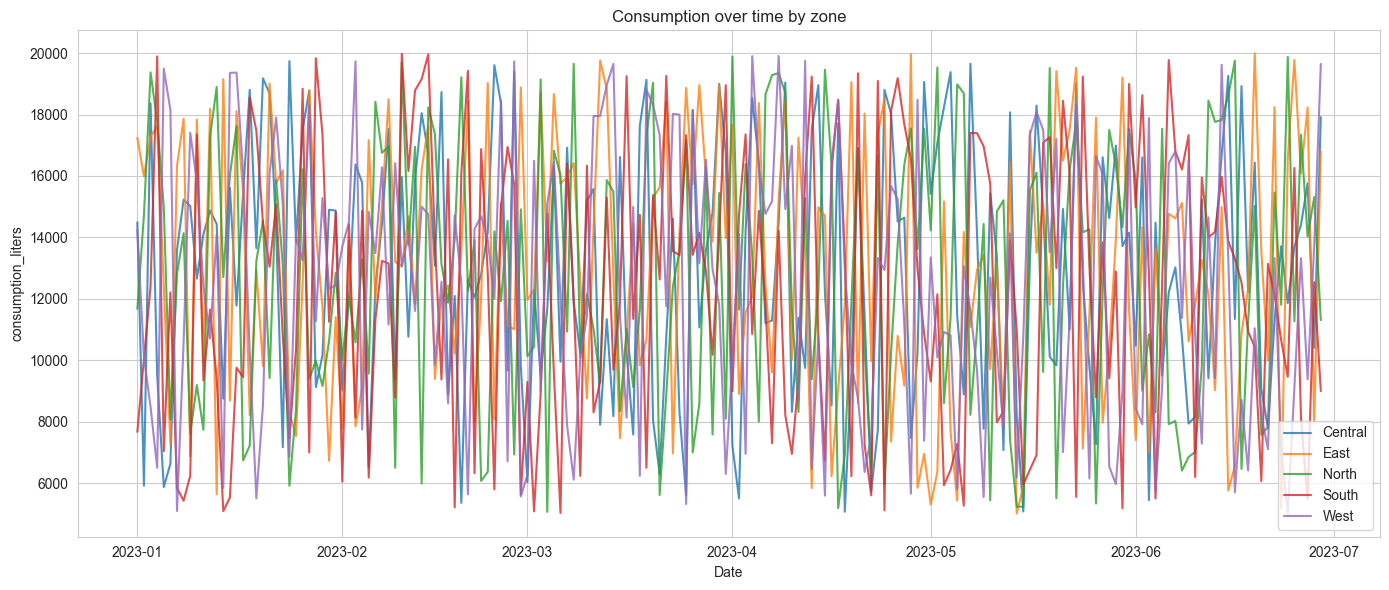

In [11]:
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')

plt.figure(figsize=(14, 6))
for zone, zone_df in df.groupby(ZONE_COL):
    zone_df = zone_df.sort_values(DATE_COL)
    plt.plot(zone_df[DATE_COL], zone_df[CONSUMPTION_COL], label=zone, alpha=0.8)
plt.legend()
plt.title("Consumption over time by zone")
plt.xlabel("Date")
plt.ylabel(CONSUMPTION_COL)
plt.tight_layout()
plt.show()


## 9. Correlation between numeric columns

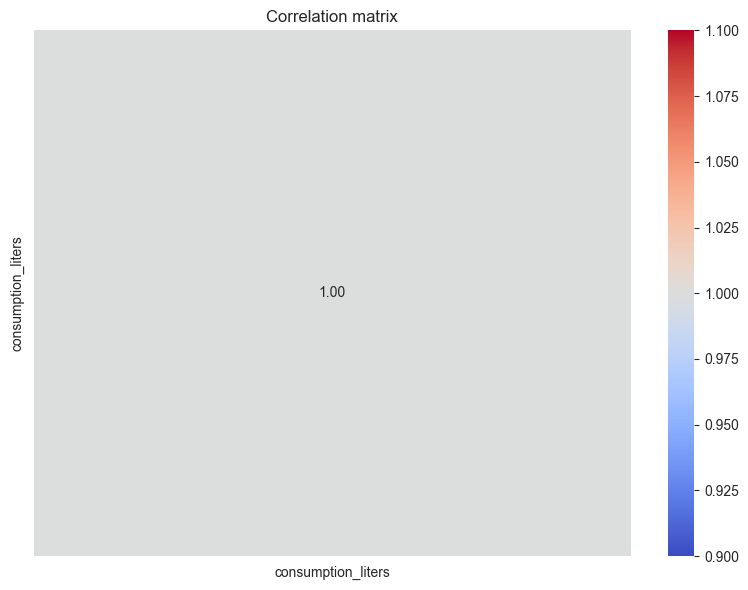

In [12]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


## 10. Notes / decisions for preprocess.py

Fill this in after reviewing the above — e.g.:
- Any columns to drop?
- Any obvious data errors (negative values, impossible spikes)?
- Confirmed column names for zone/date/consumption?
- Any zones with too little data to model reliably?

In [ ]:
# Write your findings as comments or a short markdown summary above.
